# Generation, oversampling, and traceability

Generate synthetic rows and inspect their trace records.

In [6]:
import sys
from pathlib import Path

from IPython.display import display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src" / "mimic").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
if NOTEBOOK_DIR.exists() and str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from mimic import MIMIC, GenerationPolicy, ResNetEncoder, ForestConditionalSampler, IdentityDecoder, IdentityEncoder
from mimic_notebook_utils import (
    append_generated_rows,
    cell_sampling_trace,
    class_balance,
    generated_embedding_trace,
    identity_generation_plot,
    make_two_spiral_frame,
    plot_oversampling,
)

MAJORITY_SAMPLES = 250
MINORITY_SAMPLES = MAJORITY_SAMPLES // 2

df = make_two_spiral_frame(
    majority_samples=MAJORITY_SAMPLES,
    minority_samples=MINORITY_SAMPLES,
    random_state=2,
)

display(class_balance(df).style.set_caption("Original class balance"))
display(df.head(8).style.set_caption("Original two-spiral training rows"))


,count
label,
majority,250
minority,125


,x,y,label,id
0,0.247798,0.090811,majority,0
1,0.168761,0.206043,majority,1
2,0.186642,0.008847,majority,2
3,-0.053813,0.116717,majority,3
4,0.456219,0.104372,majority,4
5,0.376696,0.070445,majority,5
6,0.197465,0.467894,majority,6
7,0.324404,0.371906,majority,7


In [7]:
mimic = MIMIC(
    ignore_columns=["id"],
    regression_columns=["x", "y"],
    classification_columns=["label"],
    encoder=ResNetEncoder(embedding_dim=8, hidden_dim=8, n_layers=2, dropout=0.05, max_epochs=30, patience=5, batch_size=64, random_state=2),
    decoder=ForestConditionalSampler(n_estimators=120, random_state=2),
    policy=GenerationPolicy(method="displacement", neighbour_mode="mutual", n_neighbors=5, lambda_range=(0.25, 0.75)),
    n_bootstrap=1,
    random_state=2,
)
mimic.fit(df)
synthetic, trace = mimic.sample(12, return_trace=True)

display(generated_embedding_trace(synthetic, trace).head(8).style.set_caption("Generated rows with embedding trace"))
display(cell_sampling_trace(trace).head(12).style.set_caption("Per-cell stochastic sampling trace"))


,x,y,label,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,decoder
0,1.752548,-1.685415,minority,314.000000,315.000000,314.000000,0.399246,mutual,ForestConditionalSampler
1,-0.638943,-2.054476,minority,305.000000,303.000000,304.000000,0.550050,mutual,ForestConditionalSampler
2,-1.112932,-1.960646,minority,304.000000,306.000000,304.000000,0.343951,mutual,ForestConditionalSampler
3,0.051881,0.467894,majority,20.000000,6.000000,16.000000,0.578717,mutual,ForestConditionalSampler
4,1.208545,1.448067,majority,114.000000,112.000000,114.000000,0.325031,mutual,ForestConditionalSampler
5,-2.117759,-1.134328,majority,162.000000,163.000000,162.000000,0.461392,mutual,ForestConditionalSampler
6,0.762846,-1.467074,majority,82.000000,85.000000,82.000000,0.733718,mutual,ForestConditionalSampler
7,-0.183195,-0.249112,minority,256.000000,258.000000,259.000000,0.343626,mutual,ForestConditionalSampler


,trace_type,sample_index,method,decoder,sweep,column,task,sampled_value,conditioning,embedding_slice_start,embedding_slice_stop,member_index,source_position,source_index,source_weight,leaf_support_size,sampled_class_code,class_probabilities
12,cell,0,gibbs_forest,ForestConditionalSampler,0.000000,x,regression,1.397878,z_minus_j,0.000000,8.000000,0.000000,189.000000,189.000000,0.009722,37.000000,nan,nan
13,cell,1,gibbs_forest,ForestConditionalSampler,0.000000,x,regression,-0.636067,z_minus_j,0.000000,8.000000,0.000000,365.000000,365.000000,0.158909,16.000000,nan,nan
14,cell,2,gibbs_forest,ForestConditionalSampler,0.000000,x,regression,-0.771232,z_minus_j,0.000000,8.000000,0.000000,304.000000,304.000000,0.196190,25.000000,nan,nan
15,cell,3,gibbs_forest,ForestConditionalSampler,0.000000,x,regression,0.051881,z_minus_j,0.000000,8.000000,0.000000,179.000000,179.000000,0.148135,19.000000,nan,nan
16,cell,4,gibbs_forest,ForestConditionalSampler,0.000000,x,regression,1.384115,z_minus_j,0.000000,8.000000,0.000000,114.000000,114.000000,0.345139,28.000000,nan,nan
17,cell,5,gibbs_forest,ForestConditionalSampler,0.000000,x,regression,-2.057080,z_minus_j,0.000000,8.000000,0.000000,164.000000,164.000000,0.022778,15.000000,nan,nan
18,cell,6,gibbs_forest,ForestConditionalSampler,0.000000,x,regression,0.762846,z_minus_j,0.000000,8.000000,0.000000,184.000000,184.000000,0.167222,27.000000,nan,nan
19,cell,7,gibbs_forest,ForestConditionalSampler,0.000000,x,regression,-0.183195,z_minus_j,0.000000,8.000000,0.000000,261.000000,261.000000,0.441111,16.000000,nan,nan
20,cell,8,gibbs_forest,ForestConditionalSampler,0.000000,x,regression,0.333620,z_minus_j,0.000000,8.000000,0.000000,182.000000,182.000000,0.110946,26.000000,nan,nan
21,cell,9,gibbs_forest,ForestConditionalSampler,0.000000,x,regression,1.351479,z_minus_j,0.000000,8.000000,0.000000,333.000000,333.000000,0.181528,25.000000,nan,nan


In [ ]:
minority_needed = df["label"].value_counts()["majority"] - df["label"].value_counts()["minority"]
minority_synthetic, minority_trace = mimic.sample(
    minority_needed,
    condition={"label": "minority"},
    return_trace=True,
)
balanced = append_generated_rows(df, minority_synthetic)

display(class_balance(balanced).style.set_caption("Class balance after minority-conditioned displacement oversampling"))
display(generated_embedding_trace(minority_synthetic, minority_trace, include_condition=True).head(8).style.set_caption("Synthetic minority rows with embedding trace"))
display(cell_sampling_trace(minority_trace).head(12).style.set_caption("Minority per-cell stochastic sampling trace"))


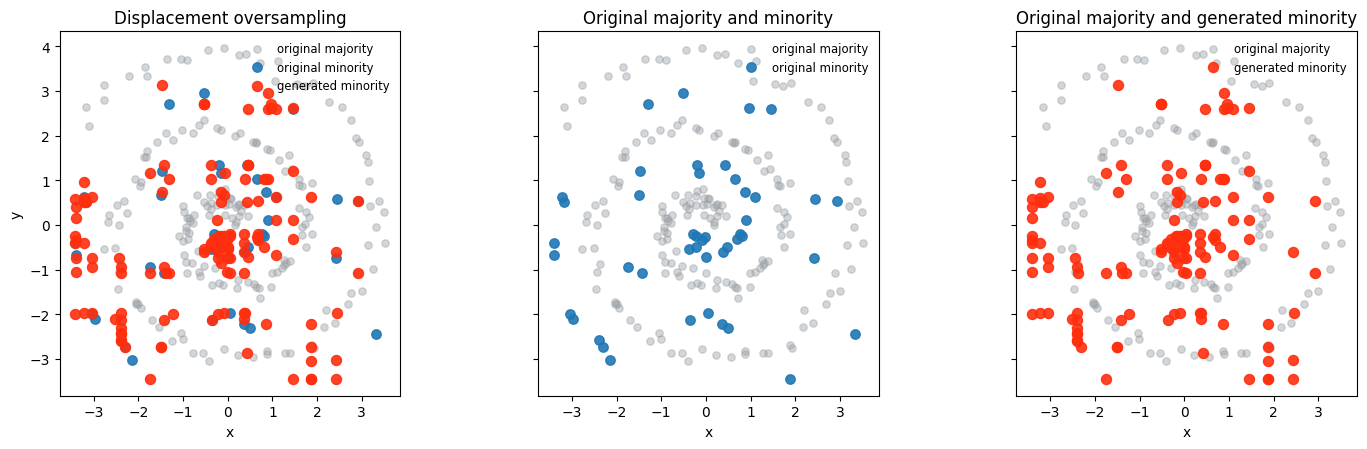

In [ ]:
fig, ax = plot_oversampling(df, minority_synthetic)


## Identity-space configurable baseline

Set the full MIMIC estimator here, using `IdentityEncoder` and `IdentityDecoder` to generate in the preprocessed original feature space. Change `identity_policy` to switch between SMOTE-style interpolation and displacement.

,method,neighbour_mode,n_neighbors,lambda_range,n_generated,trace_rows,x_min,x_max,y_min,y_max
0,displacement,mutual,5,"(0.25, 0.75)",135,135,-3.702321,3.919454,-4.154178,3.525313


,x,y,label
0,-3.123035,-0.873433,minority
1,-3.066934,-0.152188,minority
2,-3.100818,-0.683251,minority
3,0.188111,-0.052714,minority
4,1.291602,1.018698,minority
5,-1.282098,0.744476,minority
6,1.058798,0.082294,minority
7,1.796628,2.890643,minority


,trace_type,sample_index,method,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,restriction,condition,decoder,random_state
0,embedding,0,displacement,217,214,216,0.399246,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
1,embedding,1,displacement,216,214,215,0.550050,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
2,embedding,2,displacement,216,215,217,0.343951,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
3,embedding,3,displacement,182,185,182,0.578717,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
4,embedding,4,displacement,193,192,193,0.325031,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
5,embedding,5,displacement,199,213,199,0.461392,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
6,embedding,6,displacement,189,187,189,0.733718,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
7,embedding,7,displacement,210,211,210,0.445812,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2


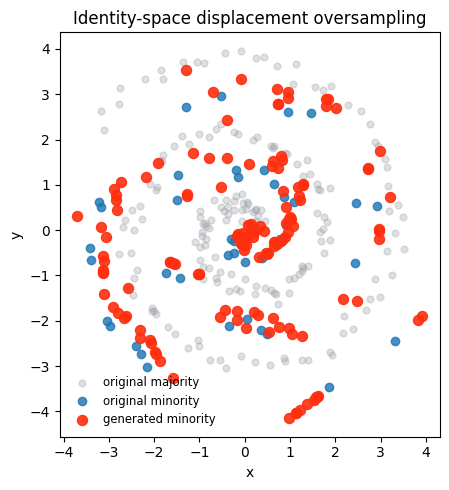

In [ ]:
identity_policy = GenerationPolicy(
    method="displacement",  # change to "displacement" for the displacement variant
    neighbour_mode="mutual",
    n_neighbors=5,
    lambda_range=(0.25, 0.75),
)

identity_mimic = MIMIC(
    ignore_columns=["id"],
    regression_columns=["x", "y"],
    classification_columns=["label"],
    encoder=IdentityEncoder(),
    decoder=IdentityDecoder(),
    policy=identity_policy,
    n_bootstrap=1,
    random_state=2,
)

identity_summary, identity_synthetic, identity_trace, identity_fig, identity_ax = identity_generation_plot(
    identity_mimic,
    df,
    n_samples=minority_needed,
    condition={"label": "minority"},
    title=f"Identity-space {identity_policy.method} oversampling",
)

display(identity_summary.style.set_caption("Identity-space generation summary"))
display(identity_synthetic.head(8).style.set_caption("Identity-space synthetic minority rows"))
display(identity_trace.head(8).style.set_caption("Identity-space generation trace"))